In [1]:
! pip install ipumspy pandas

  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 62.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 75.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.2/34.2 MB 70.2 MB/s  0:00:00 eta 0:00:01
Using cached idna-3.11-py3-none-any.whl (71 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 854.0/854.0 kB 40.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 [ipumspy]5/16 [ipumspy]]ormalizer]

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
! pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 58.5 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 41.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 60.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [1]:
import pandas as pd
from ipumspy import readers

ddi = readers.read_ipums_ddi("usa_00003.xml")



/Users/anagha/Documents/Spring 2026/capstone/CivicSim_Main/.venv/lib/python3.13/site-packages/ipumspy/readers.py:70: CitationWarning: Use of data from IPUMS is subject to conditions including that users should cite the data appropriately.
See the `ipums_conditions` attribute of this codebook for terms of use.
See the `ipums_citation` attribute of this codebook for the appropriate citation.
  warnings.warn(


In [2]:
# 10 most populous US states by FIPS code
TOP_10_STATES = {
    6,   # California
    48,  # Texas
    12,  # Florida
    36,  # New York
    42,  # Pennsylvania
    17,  # Illinois
    39,  # Ohio
    13,  # Georgia
    37,  # North Carolina
    26,  # Michigan
}

sample_chunks = []
for chunk in readers.read_microdata_chunked(ddi, chunksize=100_000, filename="../data/usa_00003.dat"):
    filtered = chunk[chunk["STATEFIP"].isin(TOP_10_STATES)]
    if len(filtered) > 0:
        sample_chunks.append(filtered)

df_sample = pd.concat(sample_chunks)
print(f"Total rows: {len(df_sample):,}")
print("States loaded:", sorted(df_sample["STATEFIP"].unique().tolist()))

Total rows: 8,918,738
States loaded: [6, 12, 13, 17, 26, 36, 37, 39, 42, 48]


In [134]:
df_sample.columns.tolist()

['YEAR',
 'SAMPLE',
 'SERIAL',
 'CBSERIAL',
 'HHWT',
 'CLUSTER',
 'STATEFIP',
 'PUMA',
 'METRO',
 'STRATA',
 'GQ',
 'OWNERSHP',
 'OWNERSHPD',
 'PERNUM',
 'PERWT',
 'SEX',
 'AGE',
 'MARST',
 'RACE',
 'RACED',
 'YRSUSA1',
 'SPEAKENG',
 'HCOVANY',
 'HCOVPRIV',
 'HCOVPUB',
 'EDUC',
 'EDUCD',
 'EMPSTAT',
 'EMPSTATD',
 'OCC',
 'IND',
 'INCTOT',
 'FTOTINC',
 'SPMPOV']

In [3]:
df = df_sample

# Keep only relevant columns
cols = [
    "YEAR", "STATEFIP", "METRO",
    "AGE", "SEX", "RACE",
    "EDUCD", "EMPSTAT",
    "INCTOT", "FTOTINC",
    "SPMPOV", "OWNERSHP"
]

df = df[cols]

In [4]:
df = df[df["AGE"] >= 18]

In [5]:
import numpy as np

# Replace 9999999 (IPUMS income missing code) across all columns
df = df.replace(9999999, np.nan)

# Replace 0 only for columns where 0 means N/A — NOT SPMPOV (0 = not in poverty)
na_zero_cols = ["METRO", "EDUCD", "EMPSTAT", "OWNERSHP"]
df[na_zero_cols] = df[na_zero_cols].replace(0, np.nan)

df = df.dropna()

In [6]:
valid_years = [2019, 2021, 2022, 2023, 2024]
df = df[df["YEAR"].isin(valid_years)]

In [174]:
len(df)

5405074

# BIN values for all attributes

In [7]:
def age_bin(x):
    if x < 30: return "18-29"
    elif x < 45: return "30-44"
    elif x < 65: return "45-64"
    else: return "65+"

df["age_group"] = df["AGE"].apply(age_bin)

In [8]:
def income_bin(x):
    if x < 30000: return "low"
    elif x < 100000: return "mid"
    else: return "high"

df["income_group"] = df["INCTOT"].apply(income_bin)

In [9]:
def edu_bin(x):
    # EDUCD codes: 0-64=hs or less (incl. diploma/GED), 65-90=some college/AA, 91-101=bachelor's, 102+=graduate
    if x <= 64: return "hs_or_less"
    elif x <= 90: return "some_college"
    elif x <= 101: return "bachelors"
    else: return "graduate"

df["education_group"] = df["EDUCD"].apply(edu_bin)

In [10]:
def emp_bin(x):
    if x == 1: return "employed"
    else: return "unemployed"

df["employment"] = df["EMPSTAT"].apply(emp_bin)

In [11]:
def housing_bin(x):
    if x == 1: return "owner"
    elif x == 2: return "renter"
    else: return "other"

df["housing"] = df["OWNERSHP"].apply(housing_bin)

In [12]:
def metro_bin(x):
    # METRO 1=not in metro area (rural); 2/3/4=metro area (urban)
    return "urban" if x in [2, 3, 4] else "rural"

df["urbanicity"] = df["METRO"].apply(metro_bin)

In [13]:
model_df = df[[
    "age_group",
    "income_group",
    "education_group",
    "employment",
    "housing",
    "urbanicity",
    "STATEFIP"
]]

In [182]:
model_df

,age_group,income_group,education_group,employment,housing,urbanicity,STATEFIP
172958,18-29,mid,bachelors,employed,renter,urban,6
172959,30-44,low,hs_or_less,unemployed,renter,urban,6
172960,18-29,low,hs_or_less,unemployed,renter,urban,6
172961,18-29,low,hs_or_less,employed,renter,urban,6
172964,30-44,low,hs_or_less,employed,renter,urban,6
...,...,...,...,...,...,...,...
12970660,30-44,low,hs_or_less,unemployed,owner,urban,48
12970661,30-44,mid,hs_or_less,employed,owner,urban,48
12970662,65+,high,some_college,employed,owner,urban,48
12970663,65+,low,some_college,unemployed,owner,urban,48


# PROBABILITY DISTRIBUTION

In [14]:
age_dist = model_df["age_group"].value_counts(normalize=True)
income_dist = model_df["income_group"].value_counts(normalize=True)

In [15]:
p_income_given_age = pd.crosstab(
    model_df["income_group"],
    model_df["age_group"],
    normalize="columns"
)

In [16]:
p_edu_given_age = pd.crosstab(
    model_df["education_group"],
    model_df["age_group"],
    normalize="columns"
)

In [17]:
p_housing_given_income = pd.crosstab(
    model_df["housing"],
    model_df["income_group"],
    normalize="columns"
)

In [187]:
### age → income → housing
    #  → education
    #  → employment

# Generate Synthetic Agents

In [18]:
def sample_from_dist(dist):
    return np.random.choice(dist.index, p=dist.values)

In [19]:
def generate_agent():
    agent = {}

    # Step 1: sample age
    agent["age"] = sample_from_dist(age_dist)

    # Step 2: sample income given age
    income_probs = p_income_given_age[agent["age"]]
    agent["income"] = np.random.choice(income_probs.index, p=income_probs.values)

    # Step 3: education
    edu_probs = p_edu_given_age[agent["age"]]
    agent["education"] = np.random.choice(edu_probs.index, p=edu_probs.values)

    # Step 4: housing
    housing_probs = p_housing_given_income[agent["income"]]
    agent["housing"] = np.random.choice(housing_probs.index, p=housing_probs.values)

    return agent

In [24]:
N = 500
agents = [generate_agent() for _ in range(N)]
agents_df = pd.DataFrame(agents)
print(f"Generated {N} synthetic agents")
agents_df.head()

Generated 500 synthetic agents


,age,income,education,housing
0,30-44,low,some_college,owner
1,45-64,low,some_college,renter
2,45-64,low,graduate,renter
3,65+,low,bachelors,owner
4,45-64,low,graduate,owner


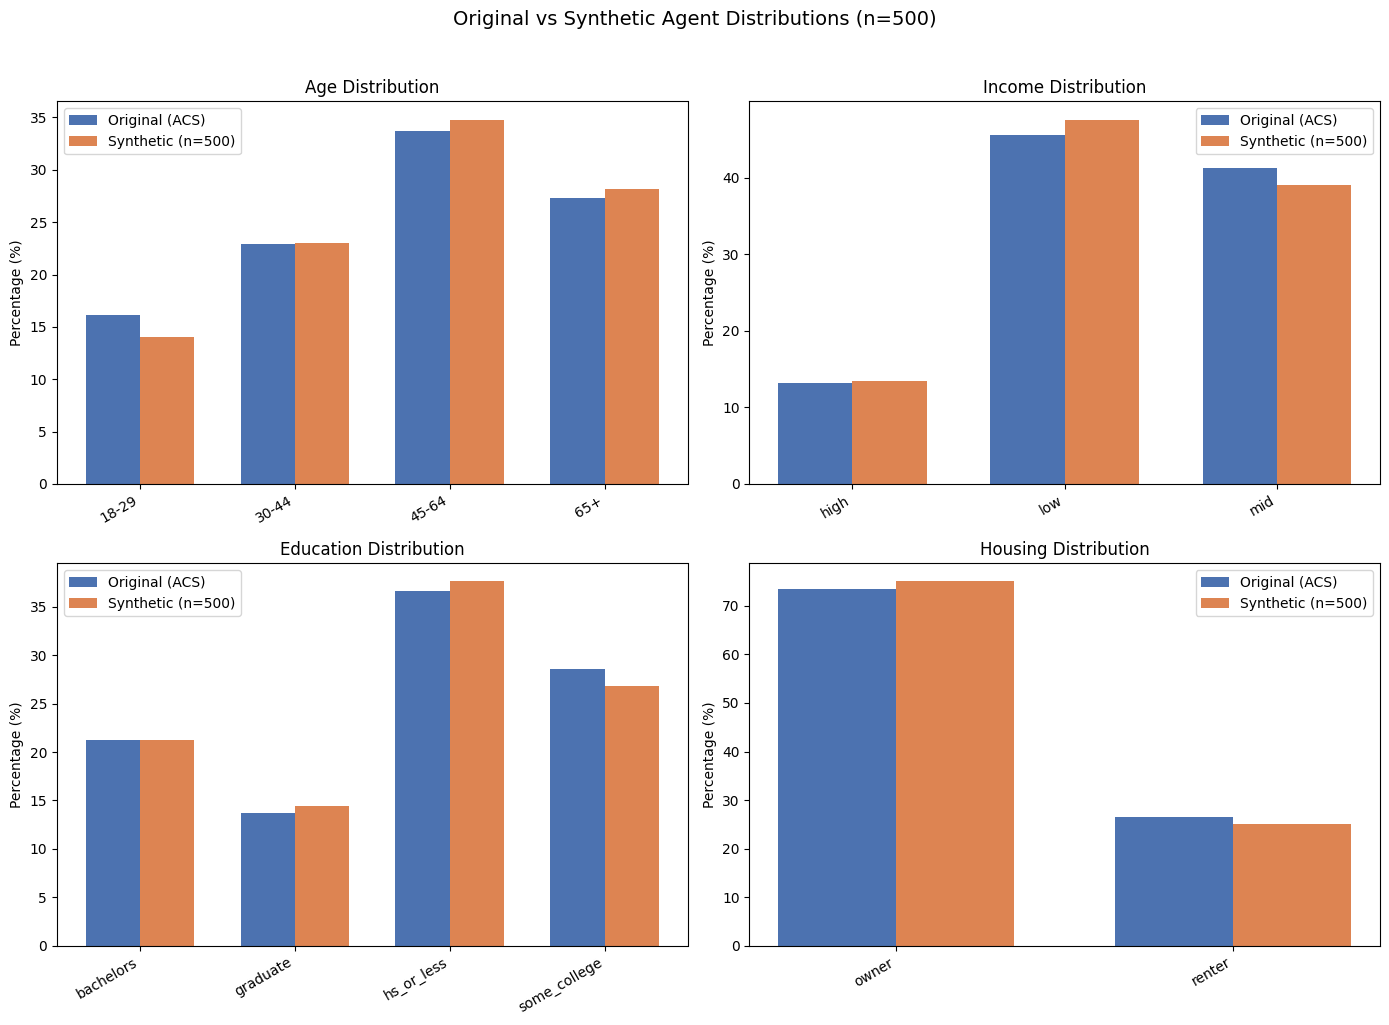

In [25]:
import matplotlib.pyplot as plt

attrs = ["age", "income", "education", "housing"]
orig_cols = ["age_group", "income_group", "education_group", "housing"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (attr, orig_col) in enumerate(zip(attrs, orig_cols)):
    ax = axes[i]

    # Original distribution
    orig_dist = model_df[orig_col].value_counts(normalize=True).sort_index()
    # Synthetic distribution
    syn_dist = agents_df[attr].value_counts(normalize=True).reindex(orig_dist.index, fill_value=0)

    x = np.arange(len(orig_dist))
    width = 0.35

    ax.bar(x - width/2, orig_dist.values * 100, width, label="Original (ACS)", color="#4C72B0")
    ax.bar(x + width/2, syn_dist.values * 100, width, label=f"Synthetic (n={N})", color="#DD8452")

    ax.set_xticks(x)
    ax.set_xticklabels(orig_dist.index, rotation=30, ha="right")
    ax.set_ylabel("Percentage (%)")
    ax.set_title(f"{attr.capitalize()} Distribution")
    ax.legend()

plt.suptitle(f"Original vs Synthetic Agent Distributions (n={N})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [26]:
# Numeric comparison table
comparison_rows = []
for attr, orig_col in zip(attrs, orig_cols):
    orig_dist = model_df[orig_col].value_counts(normalize=True).sort_index() * 100
    syn_dist = agents_df[attr].value_counts(normalize=True).reindex(orig_dist.index, fill_value=0) * 100
    for cat in orig_dist.index:
        comparison_rows.append({
            "attribute": attr,
            "category": cat,
            "original_%": round(orig_dist[cat], 2),
            "synthetic_%": round(syn_dist[cat], 2),
            "diff_pp": round(syn_dist[cat] - orig_dist[cat], 2),
        })

comp_df = pd.DataFrame(comparison_rows)
print(comp_df.to_string(index=False))

attribute     category  original_%  synthetic_%  diff_pp
      age        18-29       16.12         14.0    -2.12
      age        30-44       22.89         23.0     0.11
      age        45-64       33.70         34.8     1.10
      age          65+       27.29         28.2     0.91
   income         high       13.14         13.4     0.26
   income          low       45.63         47.6     1.97
   income          mid       41.23         39.0    -2.23
education    bachelors       21.23         21.2    -0.03
education     graduate       13.67         14.4     0.73
education   hs_or_less       36.58         37.6     1.02
education some_college       28.53         26.8    -1.73
  housing        owner       73.49         75.0     1.51
  housing       renter       26.51         25.0    -1.51


# Data Exploration

### Core Distributions

In [192]:
def percentage_dist(series):
    return (series.value_counts(normalize=True) * 100).round(2)

In [193]:
edu_dist = percentage_dist(model_df["education_group"])
print("Education Distribution (%):\n", edu_dist)

Education Distribution (%):
 education_group
hs_or_less      36.58
some_college    28.53
bachelors       21.23
graduate        13.67
Name: proportion, dtype: float64


In [194]:
housing_dist = percentage_dist(model_df["housing"])
print("Housing Distribution (%):\n", housing_dist)

Housing Distribution (%):
 housing
owner     73.49
renter    26.51
Name: proportion, dtype: float64


In [195]:
emp_dist = percentage_dist(model_df["employment"])
print("Employment Distribution (%):\n", emp_dist)

Employment Distribution (%):
 employment
employed      59.18
unemployed    40.82
Name: proportion, dtype: float64


In [196]:
income_dist = percentage_dist(model_df["income_group"])
print("Income Distribution (%):\n", income_dist)

Income Distribution (%):
 income_group
low     45.63
mid     41.23
high    13.14
Name: proportion, dtype: float64


In [197]:
age_dist = percentage_dist(model_df["age_group"])
print("Age Distribution (%):\n", age_dist)

Age Distribution (%):
 age_group
45-64    33.70
65+      27.29
30-44    22.89
18-29    16.12
Name: proportion, dtype: float64


In [198]:
urban_dist = percentage_dist(model_df["urbanicity"])
print("Urbanicity (%):\n", urban_dist)

Urbanicity (%):
 urbanicity
urban    77.85
rural    22.15
Name: proportion, dtype: float64


### Cross-Demographic Analysis

In [199]:
housing_income = pd.crosstab(
    model_df["housing"],
    model_df["income_group"],
    normalize="columns"
) * 100

print(housing_income)

income_group       high        low        mid
housing                                      
owner         85.457881  68.215387  75.523678
renter        14.542119  31.784613  24.476322


In [200]:
edu_income = pd.crosstab(
    model_df["education_group"],
    model_df["income_group"],
    normalize="columns"
) * 100

print(edu_income)

income_group          high        low        mid
education_group                                 
bachelors        36.410281  13.865260  24.539820
graduate         37.662734   5.643021  14.904711
hs_or_less        9.149176  50.725194  29.659629
some_college     16.777808  29.766526  30.895840


In [201]:
emp_age = pd.crosstab(
    model_df["employment"],
    model_df["age_group"],
    normalize="columns"
) * 100
print(emp_age)

age_group       18-29      30-44      45-64        65+
employment                                            
employed    71.241411  81.407019  71.505016  18.183822
unemployed  28.758589  18.592981  28.494984  81.816178


In [202]:
housing_urban = pd.crosstab(
    model_df["housing"],
    model_df["urbanicity"],
    normalize="columns"
) * 100
print(housing_urban)

urbanicity      rural      urban
housing                         
owner       63.388082  76.368723
renter      36.611918  23.631277


In [203]:
state_dist = percentage_dist(model_df["STATEFIP"])
print(state_dist.head(10))

STATEFIP
6     21.84
48     15.5
12    12.36
36    11.39
42     7.43
17     7.18
39     6.76
37      6.0
13      5.8
26     5.74
Name: proportion, dtype: Float64


/var/folders/y9/6j701rc172dbc6jvchgkc_740000gp/T/ipykernel_11088/643962906.py:3: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  edu_dist.plot(kind="bar")


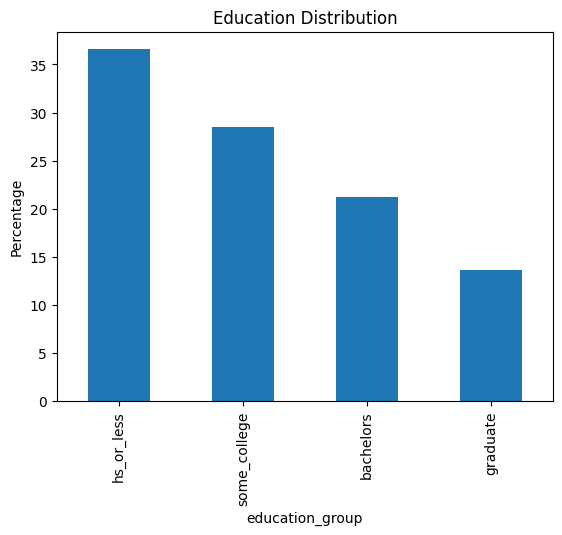

✓ civicsim_demographics.html updated


In [205]:
import matplotlib.pyplot as plt

edu_dist.plot(kind="bar")
plt.title("Education Distribution")
plt.ylabel("Percentage")
plt.show()

# ── Generate Dashboard HTML ───────────────────────────────────────────
import json, pathlib

income_age = pd.crosstab(model_df["income_group"], model_df["age_group"], normalize="columns") * 100

def vals(series, keys): return [round(float(series.get(k, 0)), 2) for k in keys]
def row(df, r, keys):   return [round(float(df.loc[r, k]), 2) for k in keys]

AGE = ["18-29", "30-44", "45-64", "65+"]
INC = ["low", "mid", "high"]
EDU = ["hs_or_less", "some_college", "bachelors", "graduate"]
top_age = age_dist.idxmax()

chart_data = {
    "meta": {
        "n_fmt":        f"{len(model_df)/1e6:.2f}M",
        "top_age":      top_age,
        "top_age_pct":  round(float(age_dist.get(top_age, 0)), 1),
        "emp_rate":     round(float(emp_dist.get("employed", 0)), 1),
        "owner_rate":   round(float(housing_dist.get("owner", 0)), 1),
        "urban_rate":   round(float(urban_dist.get("urban", 0)), 1),
        "mid_high_pct": round(float(income_dist.get("mid", 0) + income_dist.get("high", 0)), 1),
        "years":        "2019, 2021–2024",
        "states":       "CA, TX, FL, NY, PA, IL, OH, GA, NC, MI",
    },
    "age":            vals(age_dist,    AGE),
    "inc":            vals(income_dist, INC),
    "edu":            vals(edu_dist,    EDU),
    "emp_employed":   row(emp_age,        "employed",    AGE),
    "emp_unemployed": row(emp_age,        "unemployed",  AGE),
    "hu_owner":       row(housing_urban,  "owner",  ["urban", "rural"]),
    "hu_renter":      row(housing_urban,  "renter", ["urban", "rural"]),
    "ei_hs":          row(edu_income,     "hs_or_less",   INC),
    "ei_sc":          row(edu_income,     "some_college", INC),
    "ei_ba":          row(edu_income,     "bachelors",    INC),
    "ei_gr":          row(edu_income,     "graduate",     INC),
    "hi_owner":       row(housing_income, "owner",  INC),
    "hi_renter":      row(housing_income, "renter", INC),
    "ia_low":         row(income_age,     "low",  AGE),
    "ia_mid":         row(income_age,     "mid",  AGE),
    "ia_high":        row(income_age,     "high", AGE),
}

template = pathlib.Path("civicsim_demographics.html").read_text()
pathlib.Path("civicsim_demographics.html").write_text(template.replace("__DATA__", json.dumps(chart_data)))
print("✓ civicsim_demographics.html updated")

attribute     category  original_%  synthetic_%  diff_pp
      age        18-29       16.12         16.2     0.08
      age        30-44       22.89         21.2    -1.69
      age        45-64       33.70         34.4     0.70
      age          65+       27.29         28.2     0.91
   income         high       13.14         12.2    -0.94
   income          low       45.63         44.8    -0.83
   income          mid       41.23         43.0     1.77
education    bachelors       21.23         20.4    -0.83
education     graduate       13.67         13.6    -0.07
education   hs_or_less       36.58         37.4     0.82
education some_college       28.53         28.6     0.07
  housing        owner       73.49         74.6     1.11
  housing       renter       26.51         25.4    -1.11

── Per-attribute Error Metrics ──────────────────────────────────
           MAE (pp)  RMSE (pp)     TVD   KL div   chi2  p-value
attribute                                                      
age    

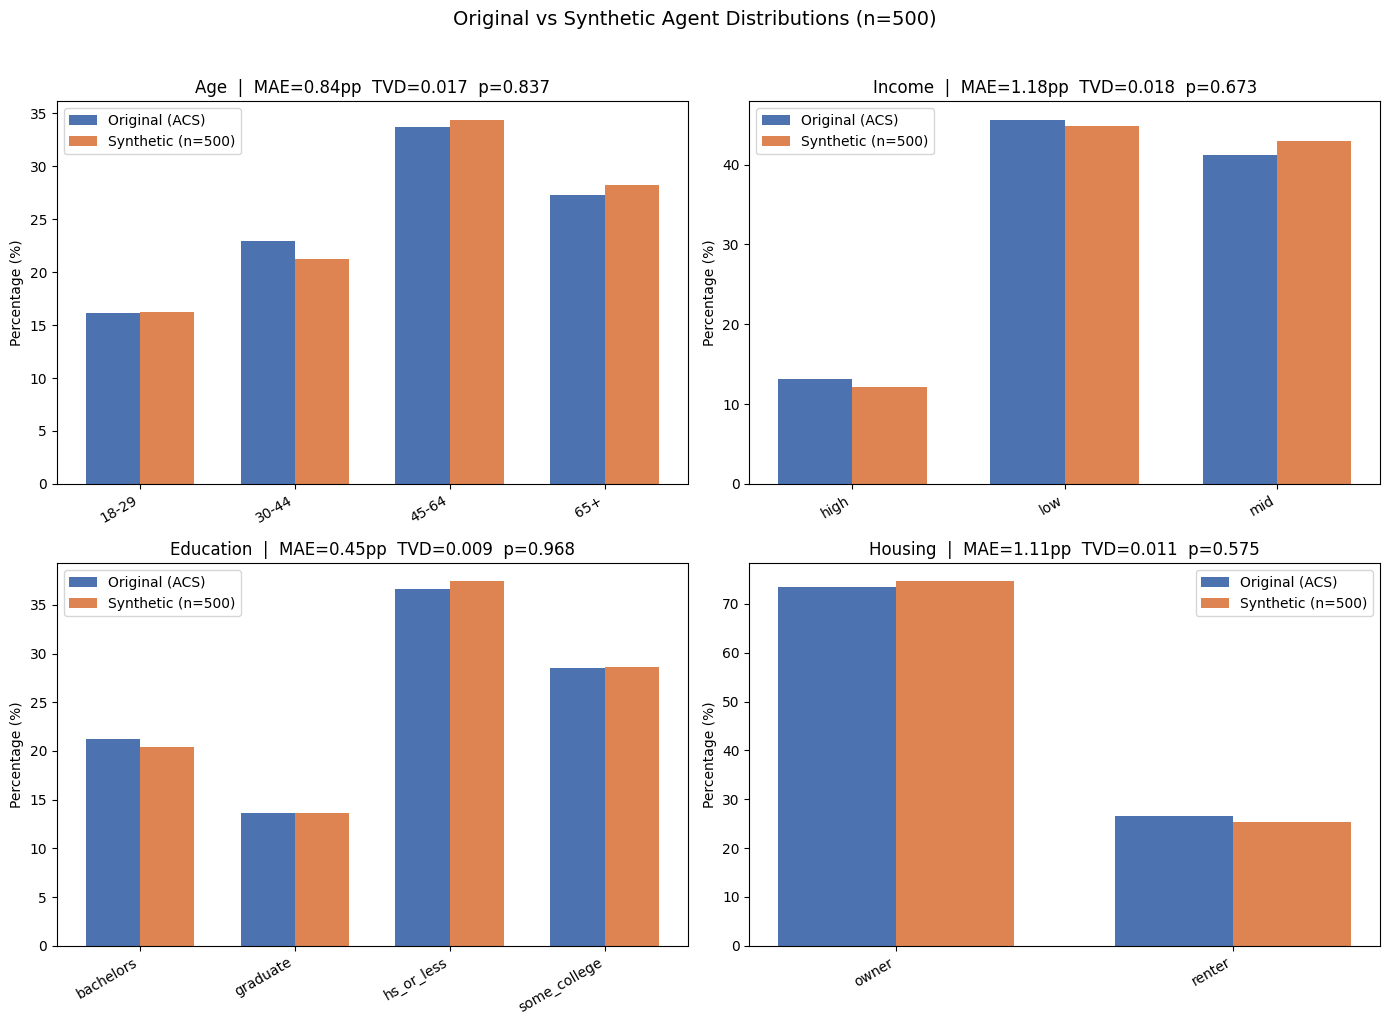

In [22]:
## ── Rerunnable Experiment Cell ────────────────────────────────────────
# Re-run this cell repeatedly to generate new agents and compare distributions.
# All logic is self-contained: generation → comparison table → metrics → bar chart.

import numpy as np, matplotlib.pyplot as plt
from scipy.special import rel_entr
from scipy.stats import chi2 as chi2_dist

N = 500  # adjust between 200–500 as needed
agents_exp = [generate_agent() for _ in range(N)]
agents_exp_df = pd.DataFrame(agents_exp)

attrs     = ["age", "income", "education", "housing"]
orig_cols = ["age_group", "income_group", "education_group", "housing"]

# ── Per-category comparison table ─────────────────────────────────────
rows = []
for attr, orig_col in zip(attrs, orig_cols):
    orig = model_df[orig_col].value_counts(normalize=True).sort_index() * 100
    syn  = agents_exp_df[attr].value_counts(normalize=True).reindex(orig.index, fill_value=0) * 100
    for cat in orig.index:
        rows.append({
            "attribute": attr, "category": cat,
            "original_%": round(orig[cat], 2),
            "synthetic_%": round(syn[cat], 2),
            "diff_pp": round(syn[cat] - orig[cat], 2),
        })

comp = pd.DataFrame(rows)
print(comp.to_string(index=False))

# ── Per-attribute error metrics ───────────────────────────────────────
# MAE (pp)  – mean absolute error across categories (in percentage points)
# RMSE (pp) – root mean squared error; penalises large deviations more
# TVD       – total variation distance = 0.5·Σ|p−q|; range [0,1]; 0 = identical
# KL div    – Kullback-Leibler divergence KL(orig ‖ syn) in nats; 0 = identical
# χ² p-val  – chi-squared goodness-of-fit; p > 0.05 ⇒ no significant deviation

metric_rows = []
for attr, orig_col in zip(attrs, orig_cols):
    orig_p = model_df[orig_col].value_counts(normalize=True).sort_index()
    syn_p  = agents_exp_df[attr].value_counts(normalize=True).reindex(orig_p.index, fill_value=1e-9)
    syn_p  = syn_p / syn_p.sum()  # renormalize after fill

    diffs = (syn_p.values - orig_p.values) * 100
    mae   = np.mean(np.abs(diffs))
    rmse  = np.sqrt(np.mean(diffs ** 2))
    tvd   = 0.5 * np.sum(np.abs(syn_p.values - orig_p.values))
    kl    = np.sum(rel_entr(orig_p.values, syn_p.values))

    # Chi-squared goodness-of-fit
    obs_counts = agents_exp_df[attr].value_counts().reindex(orig_p.index, fill_value=0)
    exp_counts = orig_p.values * N
    chi2_stat  = np.sum((obs_counts.values - exp_counts) ** 2 / exp_counts)
    p_val      = chi2_dist.sf(chi2_stat, df=len(orig_p) - 1)

    metric_rows.append({
        "attribute": attr,
        "MAE (pp)":  round(mae, 3),
        "RMSE (pp)": round(rmse, 3),
        "TVD":       round(tvd, 4),
        "KL div":    round(kl, 5),
        "chi2":      round(chi2_stat, 3),
        "p-value":   round(p_val, 4),
    })

metrics_df = pd.DataFrame(metric_rows).set_index("attribute")
print("\n── Per-attribute Error Metrics ──────────────────────────────────")
print(metrics_df.to_string())
print("\nTVD: 0 = perfect, 1 = no overlap  |  KL: 0 = identical  |  p-value > 0.05 = good fit")

# ── Bar chart with metrics in subtitles ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, (attr, orig_col) in enumerate(zip(attrs, orig_cols)):
    ax = axes.flatten()[i]
    orig = model_df[orig_col].value_counts(normalize=True).sort_index()
    syn  = agents_exp_df[attr].value_counts(normalize=True).reindex(orig.index, fill_value=0)
    x = np.arange(len(orig))
    w = 0.35
    ax.bar(x - w/2, orig.values * 100, w, label="Original (ACS)", color="#4C72B0")
    ax.bar(x + w/2, syn.values * 100,  w, label=f"Synthetic (n={N})", color="#DD8452")
    ax.set_xticks(x)
    ax.set_xticklabels(orig.index, rotation=30, ha="right")
    ax.set_ylabel("Percentage (%)")
    m = metrics_df.loc[attr]
    ax.set_title(f"{attr.capitalize()}  |  MAE={m['MAE (pp)']:.2f}pp  TVD={m['TVD']:.3f}  p={m['p-value']:.3f}")
    ax.legend()

plt.suptitle(f"Original vs Synthetic Agent Distributions (n={N})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

── 95% Confidence Intervals (50 runs × 500 agents) ─────────────
attribute     category  original_%  mean_syn_%  CI_lo (2.5%)  CI_hi (97.5%)  CI_width orig_in_CI
      age        18-29       16.12       15.83         12.47          18.40      5.93        yes
      age        30-44       22.89       22.70         20.05          26.26      6.22        yes
      age        45-64       33.70       34.14         30.34          39.04      8.70        yes
      age          65+       27.29       27.34         23.60          31.22      7.62        yes
   income         high       13.14       13.50         10.89          15.91      5.02        yes
   income          low       45.63       44.80         40.87          48.51      7.64        yes
   income          mid       41.23       41.70         37.65          45.67      8.02        yes
education    bachelors       21.23       21.12         18.14          24.35      6.22        yes
education     graduate       13.67       13.51         10.84  

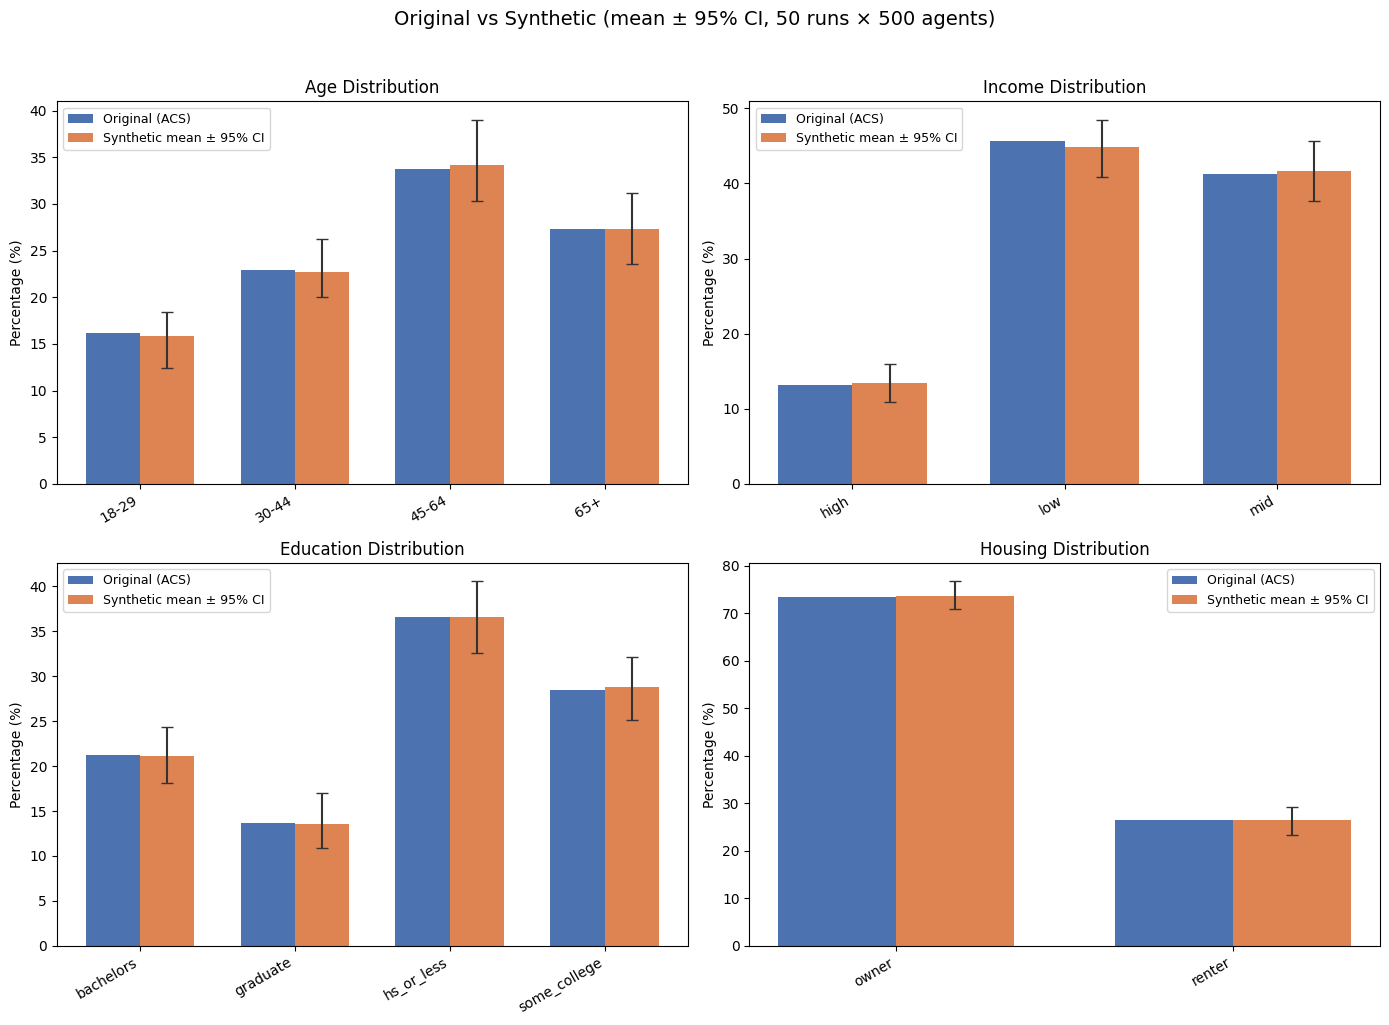

In [25]:
## ── Confidence Intervals via Repeated Experiments ─────────────────────
# Runs R independent experiments of N agents each, then computes
# 95% confidence intervals for each category's synthetic percentage.

import numpy as np, matplotlib.pyplot as plt

R = 50   # number of experiment repetitions
N = 500  # agents per experiment

attrs     = ["age", "income", "education", "housing"]
orig_cols = ["age_group", "income_group", "education_group", "housing"]

# Collect per-category percentages across R runs
run_results = {attr: {} for attr in attrs}

for r in range(R):
    agents_r = pd.DataFrame([generate_agent() for _ in range(N)])
    for attr, orig_col in zip(attrs, orig_cols):
        cats = model_df[orig_col].value_counts(normalize=True).sort_index().index
        syn_pct = agents_r[attr].value_counts(normalize=True).reindex(cats, fill_value=0) * 100
        for cat in cats:
            run_results[attr].setdefault(cat, []).append(syn_pct[cat])

# ── Summary table with 95% CI ────────────────────────────────────────
ci_rows = []
for attr, orig_col in zip(attrs, orig_cols):
    orig_pct = model_df[orig_col].value_counts(normalize=True).sort_index() * 100
    for cat in orig_pct.index:
        samples = np.array(run_results[attr][cat])
        mean = np.mean(samples)
        lo   = np.percentile(samples, 2.5)
        hi   = np.percentile(samples, 97.5)
        ci_rows.append({
            "attribute": attr, "category": cat,
            "original_%": round(float(orig_pct[cat]), 2),
            "mean_syn_%": round(mean, 2),
            "CI_lo (2.5%)": round(lo, 2),
            "CI_hi (97.5%)": round(hi, 2),
            "CI_width": round(hi - lo, 2),
            "orig_in_CI": "yes" if lo <= orig_pct[cat] <= hi else "NO",
        })

ci_df = pd.DataFrame(ci_rows)
print(f"── 95% Confidence Intervals ({R} runs × {N} agents) ─────────────")
print(ci_df.to_string(index=False))
coverage = ci_df["orig_in_CI"].value_counts(normalize=True).get("yes", 0) * 100
print(f"\nCI coverage: {coverage:.0f}% of categories contain the original value (expect ~95%)")

# ── Bar chart with error bars showing 95% CI ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, (attr, orig_col) in enumerate(zip(attrs, orig_cols)):
    ax = axes.flatten()[i]
    orig_pct = model_df[orig_col].value_counts(normalize=True).sort_index() * 100
    cats = orig_pct.index.tolist()
    means = [np.mean(run_results[attr][c]) for c in cats]
    lo    = [np.percentile(run_results[attr][c], 2.5) for c in cats]
    hi    = [np.percentile(run_results[attr][c], 97.5) for c in cats]
    errs  = [[m - l for m, l in zip(means, lo)],
             [h - m for m, h in zip(means, hi)]]

    x = np.arange(len(cats))
    w = 0.35
    ax.bar(x - w/2, orig_pct.values, w, label="Original (ACS)", color="#4C72B0")
    ax.bar(x + w/2, means, w, yerr=errs, capsize=4,
           label=f"Synthetic mean ± 95% CI", color="#DD8452", ecolor="#333")
    ax.set_xticks(x)
    ax.set_xticklabels(cats, rotation=30, ha="right")
    ax.set_ylabel("Percentage (%)")
    ax.set_title(f"{attr.capitalize()} Distribution")
    ax.legend(fontsize=9)

plt.suptitle(f"Original vs Synthetic (mean ± 95% CI, {R} runs × {N} agents)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()